# =====================================================
# Model 1: BLIP Baseline
# =====================================================

In [1]:
# =========================
# 1. Install and Imports
# =========================
!pip -q install transformers accelerate sentencepiece

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageEnhance

import torch
from google.colab import drive
from transformers import BlipProcessor, BlipForQuestionAnswering

In [2]:
# =========================
# 2. Mount Drive and Paths
# =========================
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/COMP646/final project"
DATA_PATH = os.path.join(BASE_PATH, "data")
IMG_PATH = os.path.join(DATA_PATH, "images")
TEST_JSON = os.path.join(DATA_PATH, "synthetic_vlm_test.json")

RESULTS_PATH = os.path.join(BASE_PATH, "results")
os.makedirs(RESULTS_PATH, exist_ok=True)

print("TEST_JSON:", TEST_JSON)
print("IMG_PATH:", IMG_PATH)
print("RESULTS_PATH:", RESULTS_PATH)

Mounted at /content/drive
TEST_JSON: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/data/synthetic_vlm_test.json
IMG_PATH: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/data/images
RESULTS_PATH: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/results


In [3]:
# =========================
# 3. Device Check
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [35]:
# =========================
# 4. Load Test Dataset
# =========================
with open(TEST_JSON, "r") as f:
    test_dataset = json.load(f)

print("Loaded test samples:", len(test_dataset))
print("Example query:", test_dataset[0]["query"])
print("Example answer:", test_dataset[0]["answer"])
print("Example metadata:", test_dataset[0]["metadata"])

Loaded test samples: 600
Example query: Are there more yellow triangles than green squares?
Example answer: no
Example metadata: {'query_type': 'comparison', 'target_1': {'color': 'yellow', 'shape': 'triangle', 'count': 0}, 'target_2': {'color': 'green', 'shape': 'square', 'count': 1}}


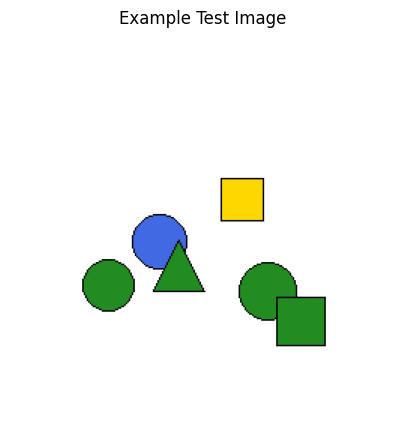

Query: Are there more yellow triangles than green squares?
Answer: no


In [37]:
# =========================
# 5. Load Image Helper
# =========================
def load_image_from_record(record):
    img_path = os.path.join(IMG_PATH, record["image_filename"])
    image = Image.open(img_path).convert("RGB")
    return image

record = test_dataset[0]
image = load_image_from_record(record)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Example Test Image")
plt.show()

print("Query:", record["query"])
print("Answer:", record["answer"])

In [38]:
# =========================
# 6. Load BLIP VQA Model
# =========================
model_name = "Salesforce/blip-vqa-base"

processor = BlipProcessor.from_pretrained(model_name)
model = BlipForQuestionAnswering.from_pretrained(model_name).to(device)

print("Loaded model:", model_name)

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: Salesforce/blip-vqa-base


In [39]:
# =========================
# 7. BLIP Wrapper
# =========================
def run_blip(image, query, max_new_tokens=5):
    inputs = processor(images=image, text=query, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)

    prediction = processor.decode(outputs[0], skip_special_tokens=True).strip()
    return prediction

In [40]:
# =========================
# 8. Perturbations
# =========================
def perturb_brightness(image, factor=0.5):
    enhancer = ImageEnhance.Brightness(image)
    return enhancer.enhance(factor)

def perturb_noise(image, noise_std=20):
    arr = np.array(image).astype(np.float32)
    noise = np.random.normal(0, noise_std, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def perturb_text_rephrase(query: str) -> str:
    q = query
    q = q.replace("Is there a", "Does the image contain a")
    q = q.replace("How many", "What number of")
    q = q.replace("are present?", "are in the image?")
    return q

In [41]:
# =========================
# 9. Normalize + Match Helpers
# =========================
def normalize_prediction(pred):
    if pred is None:
        return ""
    pred = str(pred).strip().lower()
    pred = pred.replace(".", "").replace("?", "").replace("!", "").strip()
    return pred

def is_correct_prediction(pred, answer):
    return normalize_prediction(pred) == normalize_prediction(answer)

In [42]:
# =========================
# 10. Single Sample Demo
# =========================
sample = test_dataset[0]
image = load_image_from_record(sample)
query = sample["query"]
answer = str(sample["answer"])

clean_pred = run_blip(image, query)
bright_pred = run_blip(perturb_brightness(image, 0.5), query)
noisy_pred = run_blip(perturb_noise(image, 20), query)
text_pred = run_blip(image, perturb_text_rephrase(query))

print("Query:", query)
print("Ground Truth:", answer)
print("Clean:", clean_pred)
print("Brightness:", bright_pred)
print("Noise:", noisy_pred)
print("Text:", text_pred)

Query: Are there more yellow triangles than green squares?
Ground Truth: no
Clean: yes
Brightness: yes
Noise: yes
Text: yes


In [43]:
# =========================
# 11. Batch Inference on Test Set
# =========================
blip_results = []

for i, sample in enumerate(test_dataset):
    image = load_image_from_record(sample)
    query = sample["query"]
    answer = str(sample["answer"])
    metadata = sample["metadata"]

    clean_pred = run_blip(image, query)
    bright_pred = run_blip(perturb_brightness(image, 0.5), query)
    noisy_pred = run_blip(perturb_noise(image, 20), query)
    text_query = perturb_text_rephrase(query)
    text_pred = run_blip(image, text_query)

    blip_results.append({
        "image_filename": sample["image_filename"],
        "query": query,
        "rephrased_query": text_query,
        "answer": answer,
        "metadata": metadata,
        "clean_pred": clean_pred,
        "bright_pred": bright_pred,
        "noisy_pred": noisy_pred,
        "text_pred": text_pred,
        "clean_correct": is_correct_prediction(clean_pred, answer),
        "bright_correct": is_correct_prediction(bright_pred, answer),
        "noisy_correct": is_correct_prediction(noisy_pred, answer),
        "text_correct": is_correct_prediction(text_pred, answer),
    })

    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(test_dataset)}")

Processed 50/600
Processed 100/600
Processed 150/600
Processed 200/600
Processed 250/600
Processed 300/600
Processed 350/600
Processed 400/600
Processed 450/600
Processed 500/600
Processed 550/600
Processed 600/600


In [44]:
# =========================
# 12. Save BLIP Results
# =========================
blip_results_path = os.path.join(RESULTS_PATH, "blip_results_test.json")

with open(blip_results_path, "w") as f:
    json.dump(blip_results, f, indent=2)

print("Saved BLIP results to:", blip_results_path)

Saved BLIP results to: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/results/blip_results_test.json


In [45]:
# =========================
# 13. Overall Accuracy Summary
# =========================
def mean_bool(values):
    return sum(values) / len(values) if values else 0.0

blip_clean_acc = mean_bool([r["clean_correct"] for r in blip_results])
blip_bright_acc = mean_bool([r["bright_correct"] for r in blip_results])
blip_noise_acc = mean_bool([r["noisy_correct"] for r in blip_results])
blip_text_acc = mean_bool([r["text_correct"] for r in blip_results])

print("BLIP Overall Accuracy")
print(f"Clean:      {blip_clean_acc:.3f}")
print(f"Brightness: {blip_bright_acc:.3f}")
print(f"Noise:      {blip_noise_acc:.3f}")
print(f"Text:       {blip_text_acc:.3f}")

BLIP Overall Accuracy
Clean:      0.593
Brightness: 0.590
Noise:      0.570
Text:       0.570


In [46]:
# =========================
# 14. Per Query Type Accuracy
# =========================
query_type_summary = {}

for r in blip_results:
    qtype = r["metadata"]["query_type"]

    if qtype not in query_type_summary:
        query_type_summary[qtype] = {
            "clean": [],
            "bright": [],
            "noisy": [],
            "text": []
        }

    query_type_summary[qtype]["clean"].append(r["clean_correct"])
    query_type_summary[qtype]["bright"].append(r["bright_correct"])
    query_type_summary[qtype]["noisy"].append(r["noisy_correct"])
    query_type_summary[qtype]["text"].append(r["text_correct"])

print("BLIP Per Query Type Accuracy")
for qtype, vals in query_type_summary.items():
    print(f"\nQuery Type: {qtype}")
    print(f"  Clean:  {mean_bool(vals['clean']):.3f}")
    print(f"  Bright: {mean_bool(vals['bright']):.3f}")
    print(f"  Noise:  {mean_bool(vals['noisy']):.3f}")
    print(f"  Text:   {mean_bool(vals['text']):.3f}")

BLIP Per Query Type Accuracy

Query Type: comparison
  Clean:  0.813
  Bright: 0.820
  Noise:  0.780
  Text:   0.813

Query Type: spatial
  Clean:  0.500
  Bright: 0.500
  Noise:  0.500
  Text:   0.500

Query Type: existence
  Clean:  0.779
  Bright: 0.785
  Noise:  0.767
  Text:   0.791

Query Type: count
  Clean:  0.240
  Bright: 0.213
  Noise:  0.193
  Text:   0.133


In [47]:
# =====================================================
# Clear BLIP from memory before training custom model
# =====================================================
del model
del processor
torch.cuda.empty_cache()
print("BLIP model removed. Ready for custom model.")

BLIP model removed. Ready for custom model.


# =====================================================
# Model 2: Custom Task-Specific Model
# =====================================================

In [16]:
# =====================================================
# Custom Model (Dual-Head) - Load Data + Validation Split
# =====================================================
import os
import json
import random
from collections import Counter

import numpy as np
from PIL import Image, ImageEnhance

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

TRAIN_JSON = os.path.join(DATA_PATH, "synthetic_vlm_train.json")
TEST_JSON = os.path.join(DATA_PATH, "synthetic_vlm_test.json")

with open(TRAIN_JSON, "r") as f:
    train_dataset_all = json.load(f)

with open(TEST_JSON, "r") as f:
    test_dataset_all = json.load(f)

# Use a validation split for checkpoint selection. The test set is reserved for
# final reporting only.
VALIDATION_RATIO = 0.20
SPLIT_SEED = 42

def stratified_train_val_split(records, val_ratio=0.2, seed=42):
    rng = random.Random(seed)
    by_type = {}
    for record in records:
        qtype = record["metadata"]["query_type"]
        by_type.setdefault(qtype, []).append(record)

    train_records, val_records = [], []
    for qtype, items in by_type.items():
        items = list(items)
        rng.shuffle(items)
        val_count = max(1, int(round(len(items) * val_ratio)))
        val_records.extend(items[:val_count])
        train_records.extend(items[val_count:])

    rng.shuffle(train_records)
    rng.shuffle(val_records)
    return train_records, val_records

train_records_custom, val_records_custom = stratified_train_val_split(
    train_dataset_all,
    val_ratio=VALIDATION_RATIO,
    seed=SPLIT_SEED,
)

print("Original train pool:", len(train_dataset_all))
print("Custom train split:", len(train_records_custom))
print("Validation split:", len(val_records_custom))
print("Final test samples:", len(test_dataset_all))


Original train pool: 3000
Custom train split: 2400
Validation split: 600
Final test samples: 600


In [17]:
# =====================================================
# Check Count Range
# =====================================================
train_count_answers = [
    int(s["answer"]) for s in train_dataset_all
    if s["metadata"]["query_type"] == "count"
]

test_count_answers = [
    int(s["answer"]) for s in test_dataset_all
    if s["metadata"]["query_type"] == "count"
]

max_train_count = max(train_count_answers) if train_count_answers else 0
max_test_count = max(test_count_answers) if test_count_answers else 0
max_count_value = max(max_train_count, max_test_count)

print("Max train count:", max_train_count)
print("Max test count:", max_test_count)
print("Using max count value:", max_count_value)

Max train count: 4
Max test count: 3
Using max count value: 4


In [18]:
# =====================================================
# Build Vocabulary
# =====================================================
# Build vocabulary from the custom training split only. Include deterministic
# text perturbations so the custom model does not see many <unk> tokens during
# text-robustness evaluation.
counter = Counter()

for s in train_records_custom:
    queries = [s["query"]]
    q = s["query"]
    q = q.replace("Is there a", "Does the image contain a")
    q = q.replace("How many", "What number of")
    q = q.replace("are present?", "are in the image?")
    q = q.replace("Are there more", "Does the image contain more")
    queries.append(q)

    for query in queries:
        tokens = query.lower().replace("?", "").replace(",", "").split()
        counter.update(tokens)

vocab = {"<pad>": 0, "<unk>": 1}
for word in counter:
    vocab[word] = len(vocab)

print("Vocab size:", len(vocab))


Vocab size: 31


In [19]:
# =====================================================
# Query Type Mapping + Helpers
# =====================================================
query_type_to_id = {
    "existence": 0,
    "spatial": 1,
    "comparison": 2,
    "count": 3
}

yesno_query_types = {"existence", "spatial", "comparison"}

CUSTOM_TRAINING_CONFIG = {
    "model_version": "custom_dual_head_v2_augmented",
    "image_encoder": "ResNet-18 pretrained on ImageNet",
    "text_encoder": "Bidirectional GRU",
    "fusion": "shared MLP over image + text + query-type features",
    "training_augmentation": "random clean / brightness / noise / text rephrasing",
    "brightness_factor": 0.5,
    "noise_std": 20,
    "epochs": 20,
    "batch_size": 64,
    "head_lr": 1e-3,
    "cnn_lr": 1e-5,
    "weight_decay": 1e-4,
}

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

def tokenize_query(query: str):
    return query.lower().replace("?", "").replace(",", "").split()

def encode_query(query, vocab, max_len=20):
    tokens = tokenize_query(query)
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    ids = ids[:max_len]
    ids += [vocab["<pad>"]] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def answer_to_yesno_label(answer):
    return 1 if str(answer).strip().lower() == "yes" else 0

def normalize_prediction(pred):
    if pred is None:
        return ""
    pred = str(pred).strip().lower()
    pred = pred.replace(".", "").replace("?", "").replace("!", "").strip()
    return pred

def perturb_text_rephrase_custom(query: str) -> str:
    q = query
    q = q.replace("Is there a", "Does the image contain a")
    q = q.replace("How many", "What number of")
    q = q.replace("are present?", "are in the image?")
    q = q.replace("Are there more", "Does the image contain more")
    return q

def perturb_brightness(image, factor=0.5):
    enhancer = ImageEnhance.Brightness(image)
    return enhancer.enhance(factor)

def perturb_noise(image, noise_std=20):
    arr = np.array(image).astype(np.float32)
    noise = np.random.normal(0, noise_std, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


In [20]:
# =====================================================
# Dual-Head Dataset
# =====================================================
transform_custom_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_custom_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Keep this variable name for later cells.
transform_custom = transform_custom_eval

class DualHeadVQADataset(Dataset):
    def __init__(self, records, img_path, vocab, transform=None, perturbation=None):
        self.records = records
        self.img_path = img_path
        self.vocab = vocab
        self.transform = transform
        self.perturbation = perturbation  # None / brightness / noise / text / random_train

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        sample = self.records[idx]

        image = Image.open(os.path.join(self.img_path, sample["image_filename"])).convert("RGB")
        query = sample["query"]

        active_perturbation = self.perturbation
        if active_perturbation == "random_train":
            active_perturbation = random.choice([None, None, "brightness", "noise", "text"])

        if active_perturbation == "brightness":
            image = perturb_brightness(image, factor=CUSTOM_TRAINING_CONFIG["brightness_factor"])
        elif active_perturbation == "noise":
            image = perturb_noise(image, noise_std=CUSTOM_TRAINING_CONFIG["noise_std"])

        if active_perturbation == "text":
            query = perturb_text_rephrase_custom(query)

        if self.transform is not None:
            image = self.transform(image)

        query_ids = encode_query(query, self.vocab, max_len=20)

        qtype = sample["metadata"]["query_type"]
        qtype_id = torch.tensor(query_type_to_id[qtype], dtype=torch.long)

        if qtype in yesno_query_types:
            task_group = torch.tensor(0, dtype=torch.long)  # yes/no head
            target = torch.tensor(answer_to_yesno_label(sample["answer"]), dtype=torch.long)
        else:
            task_group = torch.tensor(1, dtype=torch.long)  # count head
            target = torch.tensor(int(sample["answer"]), dtype=torch.long)

        return image, query_ids, qtype_id, task_group, target


In [21]:
# =====================================================
# Dataloaders
# =====================================================
train_dataset_custom = DualHeadVQADataset(
    train_records_custom,
    IMG_PATH,
    vocab,
    transform=transform_custom_train,
    perturbation="random_train"
)

val_dataset_custom = DualHeadVQADataset(
    val_records_custom,
    IMG_PATH,
    vocab,
    transform=transform_custom_eval,
    perturbation=None
)

test_dataset_custom = DualHeadVQADataset(
    test_dataset_all,
    IMG_PATH,
    vocab,
    transform=transform_custom_eval,
    perturbation=None
)

train_loader_custom = DataLoader(
    train_dataset_custom,
    batch_size=CUSTOM_TRAINING_CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_custom = DataLoader(
    val_dataset_custom,
    batch_size=CUSTOM_TRAINING_CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_custom = DataLoader(
    test_dataset_custom,
    batch_size=CUSTOM_TRAINING_CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader_custom))
print("Validation batches:", len(val_loader_custom))
print("Test batches:", len(test_loader_custom))
print("Custom training config:", CUSTOM_TRAINING_CONFIG)


Train batches: 38
Validation batches: 10
Test batches: 10
Custom training config: {'model_version': 'custom_dual_head_v2_augmented', 'image_encoder': 'ResNet-18 pretrained on ImageNet', 'text_encoder': 'Bidirectional GRU', 'fusion': 'shared MLP over image + text + query-type features', 'training_augmentation': 'random clean / brightness / noise / text rephrasing', 'brightness_factor': 0.5, 'noise_std': 20, 'epochs': 20, 'batch_size': 64, 'head_lr': 0.001, 'cnn_lr': 1e-05, 'weight_decay': 0.0001}


In [22]:
# =====================================================
# Dual-Head Custom Model v2
# =====================================================
class DualHeadCustomVQAModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        query_type_vocab_size=4,
        text_embed_dim=96,
        qtype_embed_dim=32,
        hidden_dim=192,
        fusion_dim=384,
        num_count_classes=7
    ):
        super().__init__()

        self.num_count_classes = num_count_classes

        # Image encoder: pretrained ResNet-18 with the classifier removed.
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()   # output 512

        # Text encoder: bidirectional GRU gives stronger query representations
        # than the original single-direction GRU.
        self.embedding = nn.Embedding(vocab_size, text_embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=text_embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Query type embedding gives the model explicit task information.
        self.qtype_embedding = nn.Embedding(query_type_vocab_size, qtype_embed_dim)

        combined_dim = 512 + (hidden_dim * 2) + qtype_embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(combined_dim, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.yesno_head = nn.Linear(fusion_dim // 2, 2)
        self.count_head = nn.Linear(fusion_dim // 2, num_count_classes)

    def forward(self, image, query_ids, query_type_ids):
        img_feat = self.cnn(image)                     # (B, 512)
        emb = self.embedding(query_ids)                # (B, L, D)
        _, h = self.gru(emb)                           # h: (2, B, H)
        text_feat = torch.cat([h[-2], h[-1]], dim=1)   # (B, 2H)
        qtype_feat = self.qtype_embedding(query_type_ids)

        shared_feat = torch.cat([img_feat, text_feat, qtype_feat], dim=1)
        shared_feat = self.fusion(shared_feat)

        yesno_logits = self.yesno_head(shared_feat)
        count_logits = self.count_head(shared_feat)

        return yesno_logits, count_logits


In [23]:
# =====================================================
# Initialize Model
# =====================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

num_count_classes = max_count_value + 1
print("num_count_classes =", num_count_classes)

custom_model = DualHeadCustomVQAModel(
    vocab_size=len(vocab),
    query_type_vocab_size=len(query_type_to_id),
    num_count_classes=num_count_classes
).to(device)

criterion_yesno = nn.CrossEntropyLoss()
criterion_count = nn.CrossEntropyLoss()

# Use a lower learning rate for the pretrained CNN and a higher one for the
# task-specific text/fusion/heads. This is usually more stable than updating
# the whole model with one relatively large learning rate.
cnn_params = list(custom_model.cnn.parameters())
non_cnn_params = [
    p for name, p in custom_model.named_parameters()
    if not name.startswith("cnn.")
]

optimizer = torch.optim.AdamW(
    [
        {"params": cnn_params, "lr": CUSTOM_TRAINING_CONFIG["cnn_lr"]},
        {"params": non_cnn_params, "lr": CUSTOM_TRAINING_CONFIG["head_lr"]},
    ],
    weight_decay=CUSTOM_TRAINING_CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CUSTOM_TRAINING_CONFIG["epochs"]
)

print("Device:", device)


num_count_classes = 5
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Device: cuda


In [24]:
# =====================================================
# Train Loop
# =====================================================
def evaluate_dual_head_overall(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, query_ids, qtype_ids, task_groups, targets in loader:
            images = images.to(device)
            query_ids = query_ids.to(device)
            qtype_ids = qtype_ids.to(device)
            task_groups = task_groups.to(device)
            targets = targets.to(device)

            yesno_logits, count_logits = model(images, query_ids, qtype_ids)

            yesno_mask = (task_groups == 0)
            count_mask = (task_groups == 1)

            if yesno_mask.sum() > 0:
                pred = yesno_logits[yesno_mask].argmax(dim=1)
                correct += (pred == targets[yesno_mask]).sum().item()
                total += yesno_mask.sum().item()

            if count_mask.sum() > 0:
                pred = count_logits[count_mask].argmax(dim=1)
                correct += (pred == targets[count_mask]).sum().item()
                total += count_mask.sum().item()

    return correct / total if total > 0 else 0.0


def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for images, query_ids, qtype_ids, task_groups, targets in loader:
        images = images.to(device)
        query_ids = query_ids.to(device)
        qtype_ids = qtype_ids.to(device)
        task_groups = task_groups.to(device)
        targets = targets.to(device)

        yesno_logits, count_logits = model(images, query_ids, qtype_ids)

        losses = []
        yesno_mask = (task_groups == 0)
        count_mask = (task_groups == 1)

        if yesno_mask.sum() > 0:
            losses.append(criterion_yesno(yesno_logits[yesno_mask], targets[yesno_mask]))

        if count_mask.sum() > 0:
            losses.append(criterion_count(count_logits[count_mask], targets[count_mask]))

        loss = torch.stack(losses).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


epochs = CUSTOM_TRAINING_CONFIG["epochs"]
best_val_acc = 0.0
best_state = None
history = []

for epoch in range(epochs):
    train_loss = train_one_epoch(custom_model, train_loader_custom)
    scheduler.step()

    train_acc = evaluate_dual_head_overall(custom_model, train_loader_custom)
    val_acc = evaluate_dual_head_overall(custom_model, val_loader_custom)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "lr_cnn": optimizer.param_groups[0]["lr"],
        "lr_heads": optimizer.param_groups[1]["lr"],
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in custom_model.state_dict().items()}

    print(
        f"Epoch {epoch+1:02d}/{epochs}: "
        f"Loss={train_loss:.4f}, Train Acc={train_acc:.3f}, "
        f"Val Acc={val_acc:.3f}, Best Val Acc={best_val_acc:.3f}"
    )

if best_state is not None:
    custom_model.load_state_dict(best_state)
    final_test_acc = evaluate_dual_head_overall(custom_model, test_loader_custom)
    print(f"Loaded best validation checkpoint with Val Acc={best_val_acc:.3f}")
    print(f"Final clean Test Acc={final_test_acc:.3f}")


Epoch 01/20: Loss=0.9064, Train Acc=0.511, Val Acc=0.490, Best Val Acc=0.490
Epoch 02/20: Loss=0.8628, Train Acc=0.541, Val Acc=0.505, Best Val Acc=0.505
Epoch 03/20: Loss=0.8385, Train Acc=0.546, Val Acc=0.503, Best Val Acc=0.505
Epoch 04/20: Loss=0.8249, Train Acc=0.591, Val Acc=0.505, Best Val Acc=0.505
Epoch 05/20: Loss=0.7977, Train Acc=0.594, Val Acc=0.525, Best Val Acc=0.525
Epoch 06/20: Loss=0.7618, Train Acc=0.612, Val Acc=0.510, Best Val Acc=0.525
Epoch 07/20: Loss=0.7357, Train Acc=0.654, Val Acc=0.542, Best Val Acc=0.542
Epoch 08/20: Loss=0.6994, Train Acc=0.672, Val Acc=0.553, Best Val Acc=0.553
Epoch 09/20: Loss=0.6632, Train Acc=0.709, Val Acc=0.577, Best Val Acc=0.577
Epoch 10/20: Loss=0.6339, Train Acc=0.718, Val Acc=0.587, Best Val Acc=0.587
Epoch 11/20: Loss=0.5961, Train Acc=0.717, Val Acc=0.585, Best Val Acc=0.587
Epoch 12/20: Loss=0.5757, Train Acc=0.734, Val Acc=0.590, Best Val Acc=0.590
Epoch 13/20: Loss=0.5388, Train Acc=0.760, Val Acc=0.612, Best Val Acc=0.612

In [25]:
# =====================================================
# Perturbed Test Loaders
# =====================================================
test_loader_clean = DataLoader(
    DualHeadVQADataset(test_dataset_all, IMG_PATH, vocab, transform=transform_custom, perturbation=None),
    batch_size=32, shuffle=False
)

test_loader_brightness = DataLoader(
    DualHeadVQADataset(test_dataset_all, IMG_PATH, vocab, transform=transform_custom, perturbation="brightness"),
    batch_size=32, shuffle=False
)

test_loader_noise = DataLoader(
    DualHeadVQADataset(test_dataset_all, IMG_PATH, vocab, transform=transform_custom, perturbation="noise"),
    batch_size=32, shuffle=False
)

test_loader_text = DataLoader(
    DualHeadVQADataset(test_dataset_all, IMG_PATH, vocab, transform=transform_custom, perturbation="text"),
    batch_size=32, shuffle=False
)

In [26]:
# =====================================================
# Overall Evaluation
# =====================================================
clean_acc_custom = evaluate_dual_head_overall(custom_model, test_loader_clean)
bright_acc_custom = evaluate_dual_head_overall(custom_model, test_loader_brightness)
noise_acc_custom = evaluate_dual_head_overall(custom_model, test_loader_noise)
text_acc_custom = evaluate_dual_head_overall(custom_model, test_loader_text)

print("Custom Dual-Head Model Overall Accuracy")
print(f"Clean:      {clean_acc_custom:.3f}")
print(f"Brightness: {bright_acc_custom:.3f}")
print(f"Noise:      {noise_acc_custom:.3f}")
print(f"Text:       {text_acc_custom:.3f}")

Custom Dual-Head Model Overall Accuracy
Clean:      0.572
Brightness: 0.573
Noise:      0.582
Text:       0.568


In [27]:
# =====================================================
# Per Query Type Evaluation
# =====================================================
def evaluate_dual_head_by_query_type(model, records, perturbation=None):
    results = {}

    for qtype in query_type_to_id.keys():
        subset = [r for r in records if r["metadata"]["query_type"] == qtype]

        loader = DataLoader(
            DualHeadVQADataset(subset, IMG_PATH, vocab, transform=transform_custom, perturbation=perturbation),
            batch_size=32,
            shuffle=False
        )

        acc = evaluate_dual_head_overall(model, loader)
        results[qtype] = acc

    return results

per_qtype_clean = evaluate_dual_head_by_query_type(custom_model, test_dataset_all, perturbation=None)
per_qtype_bright = evaluate_dual_head_by_query_type(custom_model, test_dataset_all, perturbation="brightness")
per_qtype_noise = evaluate_dual_head_by_query_type(custom_model, test_dataset_all, perturbation="noise")
per_qtype_text = evaluate_dual_head_by_query_type(custom_model, test_dataset_all, perturbation="text")

print("Custom Dual-Head Model Per Query Type Accuracy")
for qtype in query_type_to_id.keys():
    print(f"\nQuery Type: {qtype}")
    print(f"  Clean:  {per_qtype_clean[qtype]:.3f}")
    print(f"  Bright: {per_qtype_bright[qtype]:.3f}")
    print(f"  Noise:  {per_qtype_noise[qtype]:.3f}")
    print(f"  Text:   {per_qtype_text[qtype]:.3f}")

Custom Dual-Head Model Per Query Type Accuracy

Query Type: existence
  Clean:  0.610
  Bright: 0.616
  Noise:  0.605
  Text:   0.593

Query Type: spatial
  Clean:  0.508
  Bright: 0.477
  Noise:  0.523
  Text:   0.508

Query Type: comparison
  Clean:  0.633
  Bright: 0.620
  Noise:  0.627
  Text:   0.640

Query Type: count
  Clean:  0.520
  Bright: 0.560
  Noise:  0.513
  Text:   0.520


In [28]:
# =====================================================
# Save Custom Raw Results (Aligned with BLIP)
# =====================================================
def idx_to_yesno_label(idx):
    return "yes" if idx == 1 else "no"

def run_custom_dual_head_on_record(sample, perturbation=None):
    """
    Run custom dual-head model on a single sample under a specified perturbation.
    perturbation: None / "brightness" / "noise" / "text"
    Returns prediction string.
    """
    # load image
    image = Image.open(os.path.join(IMG_PATH, sample["image_filename"])).convert("RGB")

    # apply image perturbation if needed
    if perturbation == "brightness":
        image = perturb_brightness(image, factor=0.5)
    elif perturbation == "noise":
        image = perturb_noise(image, noise_std=20)

    # transform image
    image_tensor = transform_custom(image).unsqueeze(0).to(device)

    # prepare query
    query = sample["query"]
    if perturbation == "text":
        query = perturb_text_rephrase_custom(query)

    query_ids = encode_query(query, vocab, max_len=20).unsqueeze(0).to(device)

    # query type id
    qtype = sample["metadata"]["query_type"]
    qtype_id = torch.tensor([query_type_to_id[qtype]], dtype=torch.long).to(device)

    # inference
    custom_model.eval()
    with torch.no_grad():
        yesno_logits, count_logits = custom_model(image_tensor, query_ids, qtype_id)

        if qtype in yesno_query_types:
            pred_idx = yesno_logits.argmax(dim=1).item()
            pred_str = idx_to_yesno_label(pred_idx)
        else:
            pred_idx = count_logits.argmax(dim=1).item()
            pred_str = str(pred_idx)

    return pred_str, query

In [29]:
# =====================================================
# Generate Per-Sample Results for Custom Model
# =====================================================
custom_results = []

for i, sample in enumerate(test_dataset_all):
    answer = str(sample["answer"])
    metadata = sample["metadata"]

    # clean
    clean_pred, clean_query = run_custom_dual_head_on_record(sample, perturbation=None)

    # brightness
    bright_pred, _ = run_custom_dual_head_on_record(sample, perturbation="brightness")

    # noise
    noisy_pred, _ = run_custom_dual_head_on_record(sample, perturbation="noise")

    # text
    text_pred, rephrased_query = run_custom_dual_head_on_record(sample, perturbation="text")

    result = {
        "image_filename": sample["image_filename"],
        "query": sample["query"],
        "rephrased_query": rephrased_query,
        "answer": answer,
        "metadata": metadata,

        "clean_pred": clean_pred,
        "bright_pred": bright_pred,
        "noisy_pred": noisy_pred,
        "text_pred": text_pred,

        "clean_correct": (clean_pred == answer),
        "bright_correct": (bright_pred == answer),
        "noisy_correct": (noisy_pred == answer),
        "text_correct": (text_pred == answer),
    }

    custom_results.append(result)

    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(test_dataset_all)}")

Processed 50/600
Processed 100/600
Processed 150/600
Processed 200/600
Processed 250/600
Processed 300/600
Processed 350/600
Processed 400/600
Processed 450/600
Processed 500/600
Processed 550/600
Processed 600/600


In [30]:
# =====================================================
# Save Custom Raw Results
# =====================================================
custom_results_path = os.path.join(RESULTS_PATH, "custom_results_test.json")

with open(custom_results_path, "w") as f:
    json.dump(custom_results, f, indent=2)

print("Saved custom raw results to:", custom_results_path)

Saved custom raw results to: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/results/custom_results_test.json


In [31]:
# =====================================================
# Recompute Custom Summary from Raw Results
# =====================================================
def mean_bool(values):
    return sum(values) / len(values) if values else 0.0

custom_overall_from_raw = {
    "clean": mean_bool([r["clean_correct"] for r in custom_results]),
    "brightness": mean_bool([r["bright_correct"] for r in custom_results]),
    "noise": mean_bool([r["noisy_correct"] for r in custom_results]),
    "text": mean_bool([r["text_correct"] for r in custom_results]),
}

custom_per_qtype_from_raw = {}
for r in custom_results:
    qtype = r["metadata"]["query_type"]

    if qtype not in custom_per_qtype_from_raw:
        custom_per_qtype_from_raw[qtype] = {
            "clean": [],
            "brightness": [],
            "noise": [],
            "text": []
        }

    custom_per_qtype_from_raw[qtype]["clean"].append(r["clean_correct"])
    custom_per_qtype_from_raw[qtype]["brightness"].append(r["bright_correct"])
    custom_per_qtype_from_raw[qtype]["noise"].append(r["noisy_correct"])
    custom_per_qtype_from_raw[qtype]["text"].append(r["text_correct"])

for qtype in custom_per_qtype_from_raw:
    for k in custom_per_qtype_from_raw[qtype]:
        custom_per_qtype_from_raw[qtype][k] = mean_bool(custom_per_qtype_from_raw[qtype][k])

print("Custom Overall (from raw):", custom_overall_from_raw)
print("Custom Per Query Type (from raw):", custom_per_qtype_from_raw)

Custom Overall (from raw): {'clean': 0.5716666666666667, 'brightness': 0.5733333333333334, 'noise': 0.5766666666666667, 'text': 0.5683333333333334}
Custom Per Query Type (from raw): {'comparison': {'clean': 0.6333333333333333, 'brightness': 0.62, 'noise': 0.62, 'text': 0.64}, 'spatial': {'clean': 0.5078125, 'brightness': 0.4765625, 'noise': 0.5234375, 'text': 0.5078125}, 'existence': {'clean': 0.6104651162790697, 'brightness': 0.6162790697674418, 'noise': 0.622093023255814, 'text': 0.5930232558139535}, 'count': {'clean': 0.52, 'brightness': 0.56, 'noise': 0.5266666666666666, 'text': 0.52}}


In [32]:
# =====================================================
# Save Consistent Custom Summary
# =====================================================
custom_summary_from_raw = {
    "overall": custom_overall_from_raw,
    "per_query_type": custom_per_qtype_from_raw
}

custom_summary_from_raw_path = os.path.join(RESULTS_PATH, "custom_dual_head_summary_test.json")

with open(custom_summary_from_raw_path, "w") as f:
    json.dump(custom_summary_from_raw, f, indent=2)

print("Saved consistent custom summary to:", custom_summary_from_raw_path)

Saved consistent custom summary to: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/results/custom_dual_head_summary_test.json


In [33]:
# =====================================================
# Save Model
# =====================================================
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "custom_dual_head_model.pth")

checkpoint = {
    "model_state_dict": custom_model.state_dict(),
    "vocab": vocab,
    "num_count_classes": num_count_classes,
    "query_type_to_id": query_type_to_id,
    "training_config": CUSTOM_TRAINING_CONFIG,
    "training_history": history,
    "validation_ratio": VALIDATION_RATIO,
    "split_seed": SPLIT_SEED,
    "best_val_acc": best_val_acc,
    "final_clean_test_acc": final_test_acc,
}

torch.save(checkpoint, MODEL_SAVE_PATH)

print("Model checkpoint saved to:", MODEL_SAVE_PATH)
print("Best validation accuracy:", best_val_acc)
print("Final clean test accuracy:", final_test_acc)


Model checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/custom_dual_head_model.pth
Best validation accuracy: 0.62
Final clean test accuracy: 0.5716666666666667


In [34]:
# The model is saved in the previous cell as a full checkpoint containing:
# model_state_dict, vocab, model/training config, and training history.
print("Custom model checkpoint already saved at:", MODEL_SAVE_PATH)


Custom model checkpoint already saved at: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/custom_dual_head_model.pth
